# Student Stress Level Classification Project
**Course:** Artificial Intelligence (CS 481)  
**Task:** Supervised machine learning classification to predict student stress level.

## 1. Problem Statement
This project aims to predict whether a student is under **low stress** or **high stress** using behavioral and academic indicators.
Accurate stress prediction can help educational institutions identify at-risk students early and design timely interventions such as counseling, workload balancing, and academic support.

## 2. Dataset Description
The dataset is a real-world student stress dataset stored in `student_stress.csv`.
It includes features related to peer pressure, academic pressure at home, study environment, coping strategy, bad habits, and academic competition.
The original target variable is `Aca_stress_rate` (stress score). In this project, it is converted into a binary target `stress_level`:
- `0` = Low Stress
- `1` = High Stress

In [17]:
# Import required libraries and load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv('student_stress.csv')

print('Dataset shape:', df.shape)
display(df.head())

print('\nColumn names:')
print(df.columns.tolist())

print('\nData types:')
display(df.dtypes)

Dataset shape: (140, 12)


,Aca_stage,Peer_press,Aca_press_home,Study_environment,Coping_strategy,bad_habits,Aca_comp_rate,Aca_stress_rate,year,month,day,semester
0,1,4,5,2,1,0,3,5,2025,7,24,2
1,1,3,4,1,1,0,3,3,2025,7,24,2
2,1,1,1,1,2,0,2,4,2025,7,24,2
3,1,3,2,1,1,0,4,3,2025,7,24,2
4,1,3,3,1,1,0,4,5,2025,7,24,2



Column names:
['Aca_stage', 'Peer_press', 'Aca_press_home', 'Study_environment', 'Coping_strategy', 'bad_habits', 'Aca_comp_rate', 'Aca_stress_rate', 'year', 'month', 'day', 'semester']

Data types:


Aca_stage            int64
Peer_press           int64
Aca_press_home       int64
Study_environment    int64
Coping_strategy      int64
bad_habits           int64
Aca_comp_rate        int64
Aca_stress_rate      int64
year                 int64
month                int64
day                  int64
semester             int64
dtype: object

## 3. Data Preprocessing
In this stage we clean and prepare the data for machine learning.
Steps performed:
1. Check missing values and duplicates.
2. Remove duplicate rows.
3. Convert `Aca_stress_rate` into binary target `stress_level` (1 if score >= 3, else 0).
4. Drop unnecessary date columns (`year`, `month`, `day`) that are not useful for behavior-based prediction.

In [18]:
# 3.1 Check for missing values
missing_values = df.isnull().sum()
print('Missing values per column:')
display(missing_values)

# 3.2 Check and remove duplicates
duplicate_count = df.duplicated().sum()
print('Number of duplicate rows before cleaning:', duplicate_count)
df = df.drop_duplicates().copy()
print('Dataset shape after dropping duplicates:', df.shape)

# 3.3 Create binary target variable
df['stress_level'] = (df['Aca_stress_rate'] >= 3).astype(int)

# 3.4 Drop unnecessary columns
columns_to_drop = ['Aca_stress_rate', 'year', 'month', 'day']
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=existing_columns_to_drop)

print('\nPreview after preprocessing:')
display(df.head())

Missing values per column:


Aca_stage            0
Peer_press           0
Aca_press_home       0
Study_environment    0
Coping_strategy      0
bad_habits           0
Aca_comp_rate        0
Aca_stress_rate      0
year                 0
month                0
day                  0
semester             0
dtype: int64

Number of duplicate rows before cleaning: 6
Dataset shape after dropping duplicates: (134, 12)

Preview after preprocessing:


,Aca_stage,Peer_press,Aca_press_home,Study_environment,Coping_strategy,bad_habits,Aca_comp_rate,semester,stress_level
0,1,4,5,2,1,0,3,2,1
1,1,3,4,1,1,0,3,2,1
2,1,1,1,1,2,0,2,2,1
3,1,3,2,1,1,0,4,2,1
4,1,3,3,1,1,0,4,2,1


## 4. Exploratory Data Analysis (EDA)
EDA helps us understand class balance and relationships between variables before model training.
We include:
- Countplot of stress levels
- Correlation heatmap

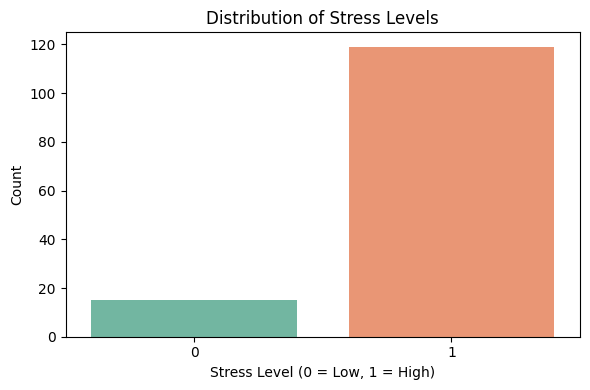

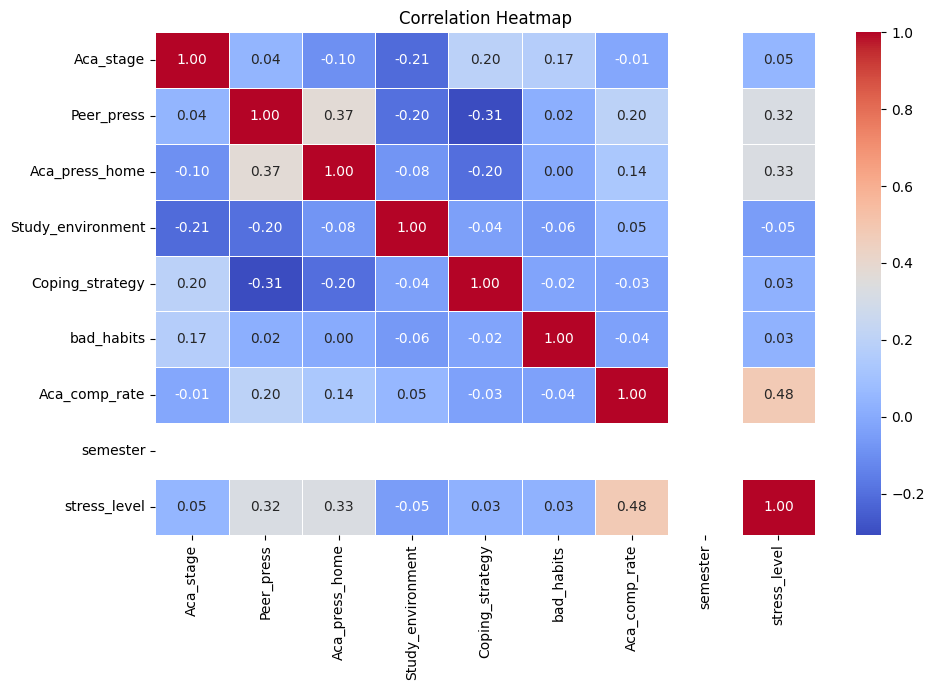

In [26]:
# Plot stress level distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='stress_level', hue='stress_level', palette='Set2', legend=False)
plt.title('Distribution of Stress Levels')
plt.xlabel('Stress Level (0 = Low, 1 = High)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Key Insights from EDA
- The countplot shows how balanced or imbalanced the two stress classes are.
- The heatmap highlights which variables move together and which are likely useful predictors.
- Features with stronger correlation to `stress_level` may contribute more to classification performance.

## 5. Feature Selection
We define:
- `X`: input features (all predictors)
- `y`: target (`stress_level`)
These features are relevant because they describe academic and behavioral factors that can directly influence student stress.

In [20]:
# Define features and target
X = df.drop(columns=['stress_level'])
y = df['stress_level']

print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)
print('\nSelected features:')
print(X.columns.tolist())

Feature matrix shape: (134, 8)
Target vector shape: (134,)

Selected features:
['Aca_stage', 'Peer_press', 'Aca_press_home', 'Study_environment', 'Coping_strategy', 'bad_habits', 'Aca_comp_rate', 'semester']


## 6. Train/Test Split
We split the dataset into 80% training and 20% testing.
This allows us to train the models on one portion of data and evaluate generalization on unseen data.

In [21]:
# Split data into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train distribution:')
print(y_train.value_counts(normalize=True))
print('\ny_test distribution:')
print(y_test.value_counts(normalize=True))

X_train shape: (107, 8)
X_test shape: (27, 8)
y_train distribution:
stress_level
1    0.88785
0    0.11215
Name: proportion, dtype: float64

y_test distribution:
stress_level
1    0.888889
0    0.111111
Name: proportion, dtype: float64


## 7. Feature Scaling
We apply `StandardScaler` so numerical features are placed on a comparable scale.
This is especially important for Logistic Regression because it is sensitive to feature magnitudes.

In [22]:
# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Scaling completed.')

Scaling completed.


## 8. Modeling
We train three supervised classification models:
1. Logistic Regression (`max_iter=1000`)
2. Decision Tree
3. Random Forest

In [23]:
# Initialize and train models
log_reg = LogisticRegression(max_iter=1000, random_state=42)
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(random_state=42)

# Logistic Regression uses scaled data
log_reg.fit(X_train_scaled, y_train)

# Tree models can use original unscaled data
decision_tree.fit(X_train, y_train)
random_forest.fit(X_train, y_train)

print('All models trained successfully.')

All models trained successfully.


## 9. Evaluation and Comparison
We evaluate all models using **accuracy score** and then generate a confusion matrix for the best model.

,Model,Accuracy
0,Logistic Regression,0.888889
1,Decision Tree,0.888889
2,Random Forest,0.851852


Best model based on accuracy: Logistic Regression


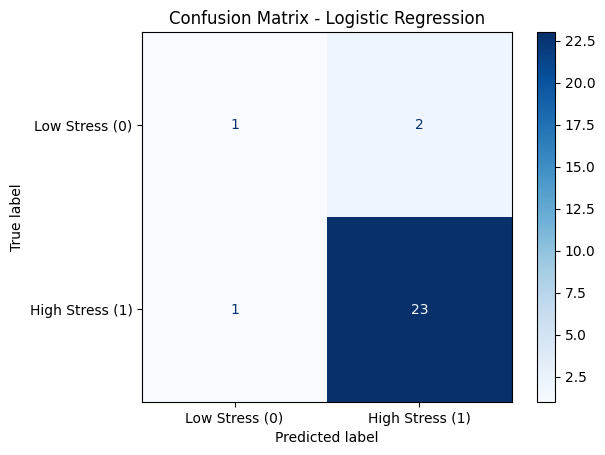

In [24]:
# Predictions
pred_log = log_reg.predict(X_test_scaled)
pred_tree = decision_tree.predict(X_test)
pred_rf = random_forest.predict(X_test)

# Accuracy scores
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, pred_log),
        accuracy_score(y_test, pred_tree),
        accuracy_score(y_test, pred_rf)
    ]
}).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

display(results)

best_model_name = results.loc[0, 'Model']
print('Best model based on accuracy:', best_model_name)

# Confusion matrix for best model
if best_model_name == 'Logistic Regression':
    best_pred = pred_log
elif best_model_name == 'Decision Tree':
    best_pred = pred_tree
else:
    best_pred = pred_rf

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Stress (0)', 'High Stress (1)'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

## 10. Feature Importance (Random Forest)
Random Forest provides feature importance scores that indicate how much each variable contributes to prediction decisions.
This helps identify the strongest factors influencing student stress.

,Importance
Aca_comp_rate,0.425033
Aca_press_home,0.167208
Peer_press,0.150282
Coping_strategy,0.100752
Study_environment,0.075117
Aca_stage,0.071592
bad_habits,0.010016
semester,0.000000


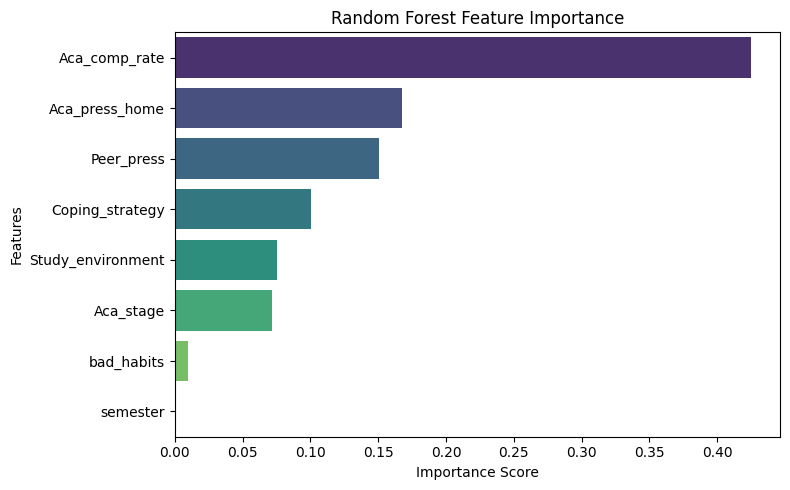

In [27]:
# Feature importance from Random Forest
importances = pd.Series(random_forest.feature_importances_, index=X.columns).sort_values(ascending=False)

display(importances.to_frame('Importance'))

plt.figure(figsize=(8, 5))
sns.barplot(
    x=importances.values,
    y=importances.index,
    hue=importances.index,
    palette='viridis',
    legend=False
    )
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## 11. Final Conclusion
This project developed a complete supervised learning pipeline to classify students into low-stress and high-stress groups.
After comparing Logistic Regression, Decision Tree, and Random Forest, the model with the highest test accuracy is selected as the final model.
The analysis of feature importance shows which academic and behavioral factors are most influential for student stress prediction.

### Real-World Application
Universities can integrate this predictive approach into student support systems to identify vulnerable students early and provide targeted interventions such as counseling, mentoring, and study-planning support.